In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [5]:
from src.fetch import fetch_from_yahoo
from src.db import load_to_sql
from src.features import add_features
ticker = "AAPL"

if __name__ == "__main__":

    df = fetch_from_yahoo(ticker=ticker)
    load_to_sql(stock)
    df_feature = add_features(stock)


[*********************100%***********************]  1 of 1 completed

✅ Fetched AAPL | 1255 trading days
✅ Connected to PostgreSQL and data saved
✅ Features added for AAPL | Shape: (1255, 9)


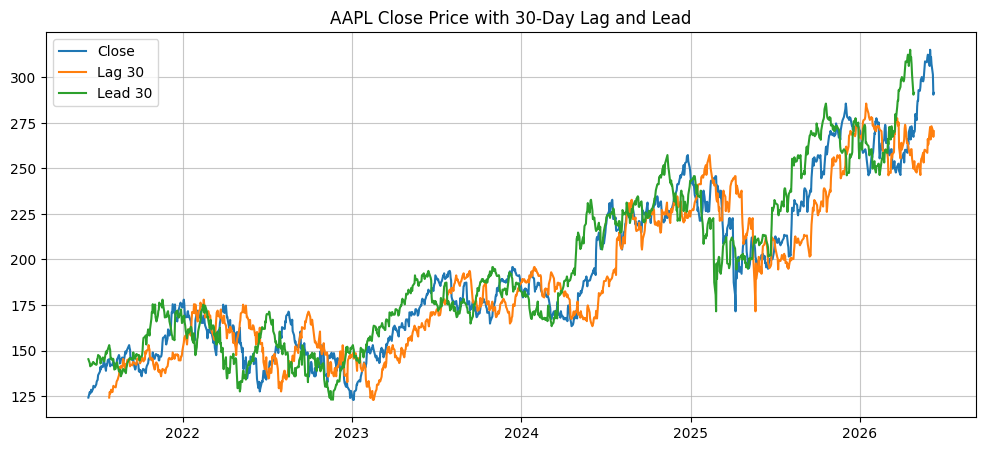

In [6]:
plt.figure(figsize=(12,5))
plt.plot(df["AAPL"],label='Close')
plt.plot(df["AAPL"].shift(30),label='Lag 30')
plt.plot(df["AAPL"].shift(-30),label='Lead 30')
plt.grid(alpha=0.7)
plt.legend()
plt.title("AAPL Close Price with 30-Day Lag and Lead")
plt.show()

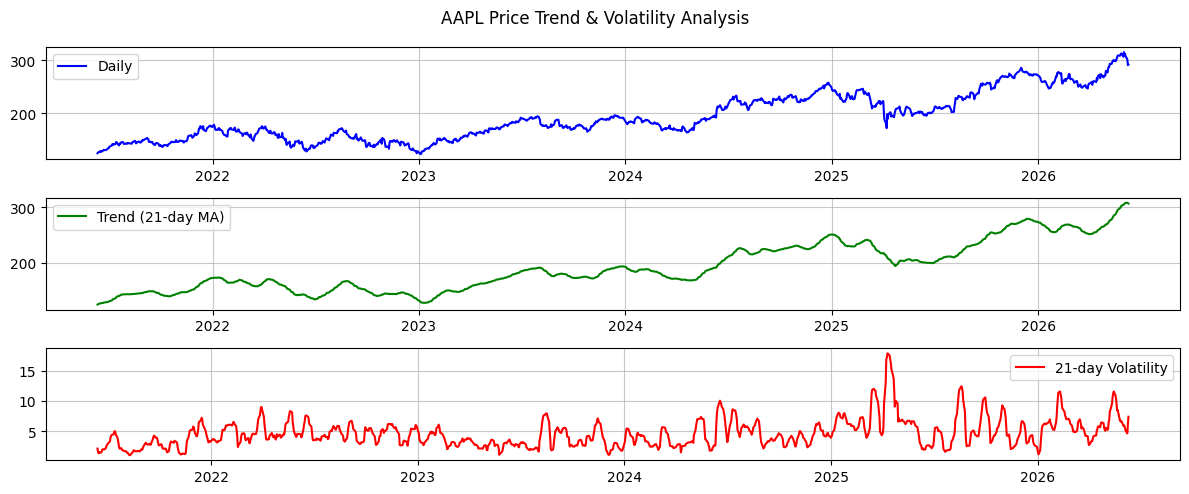

In [32]:
fig, axes = plt.subplots(3,1,figsize=(12,5))
axes[0].plot(df["AAPL"],'b-',label="Daily")
axes[1].plot(df["AAPL"].rolling(window='21D').mean(),'g-',label="Trend (21-day MA)")
axes[2].plot(df["AAPL"].rolling(window='21D').std(),'r-',label="21-day Volatility")
for ax in axes:
    ax.grid(alpha=0.7)
    ax.legend()
plt.suptitle("AAPL Price Trend & Volatility Analysis")
plt.tight_layout()
plt.show()

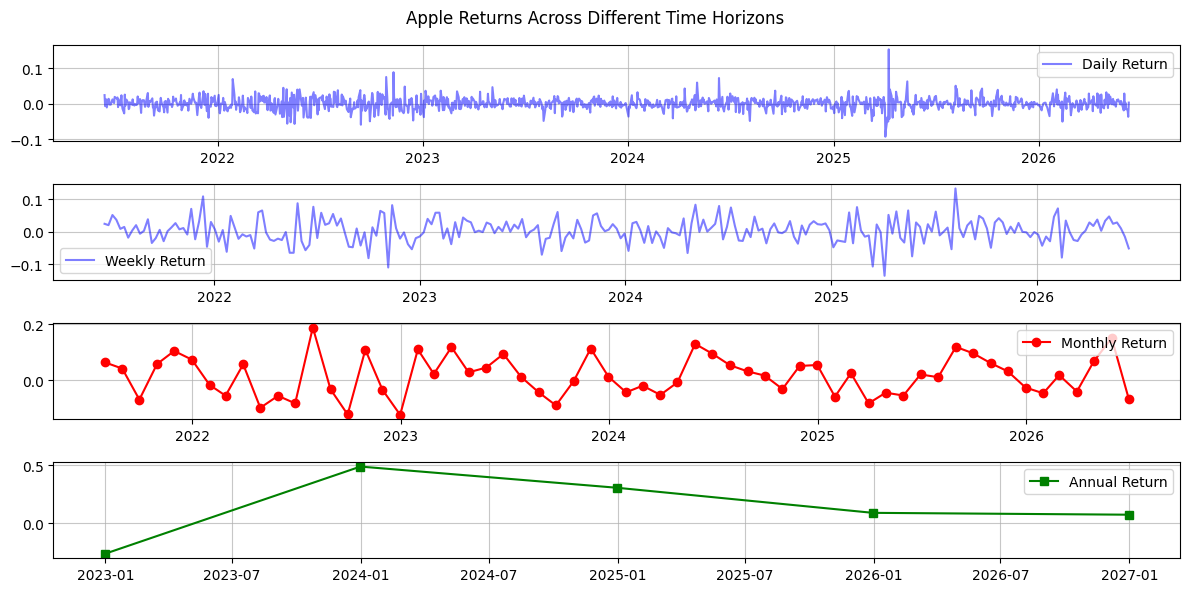

In [9]:
fig, axes = plt.subplots(4,1,figsize=(12, 6))
axes[0].plot(df["AAPL"].pct_change(periods=1),
             'b-',label="Daily Return",alpha=0.5)
axes[1].plot(df["AAPL"].resample("W").last().pct_change(periods=1),
             'b-',label="Weekly Return",alpha=0.5)
axes[2].plot(df["AAPL"].resample("ME").last().pct_change(periods=1),
             'ro-',label="Monthly Return")
axes[3].plot(df["AAPL"].resample("YE").last().pct_change(periods=1),
             'gs-',label="Annual Return")
plt.suptitle("Apple Returns Across Different Time Horizons")
plt.tight_layout()
for ax in axes:
    ax.grid(alpha=0.7)
    ax.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12,5))
cumulative_return = df[ticker].pct_change().add(1).cumprod().sub(1).mul(100)
plt.plot(cumulative_return, 'k--', linewidth=2,label = f"Baseline: {ticker} %")
plt.axhline(0, linestyle='--', color='black', alpha=0.3)
plt.legend()
plt.grid(alpha=0.7)
plt.title("Cumulative Return Comparison (%)")
plt.show()

NameError: name 'tickers' is not defined

<Figure size 1200x500 with 0 Axes>

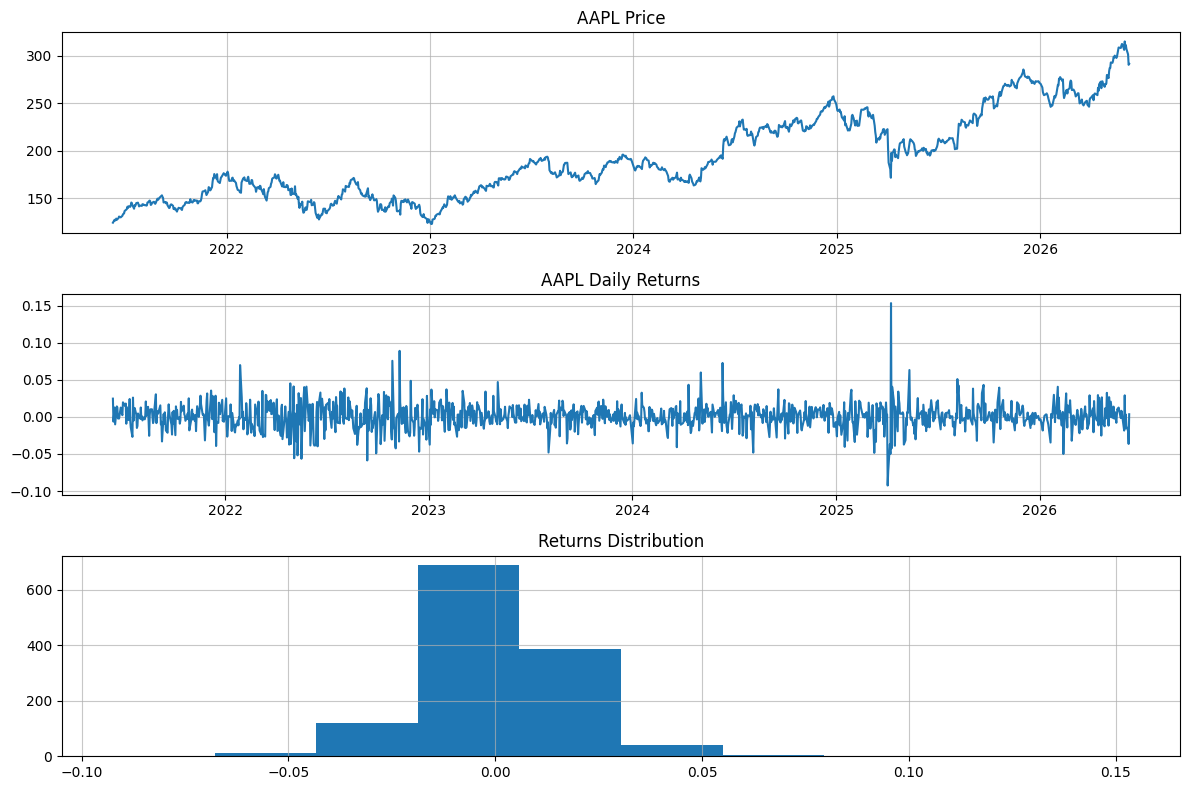

In [11]:
# Price plot — trending → likely non-stationary
fig,axis = plt.subplots(3,1,figsize=(12, 8))
axis[0].plot(df['AAPL'])
axis[0].set_title('AAPL Price')
returns = df['AAPL'].pct_change()
axis[1].plot(returns)
axis[1].set_title('AAPL Daily Returns')
axis[2].hist(returns)
axis[2].set_title('Returns Distribution')
for ax in axis:
    ax.grid(alpha=0.7)
plt.tight_layout()
plt.show()